<a href="https://colab.research.google.com/github/stswitalski/ST1_Assignment2/blob/main/Week6Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<class 'PIL.PngImagePlugin.PngImageFile'>
PNG
RGB
(464, 464)


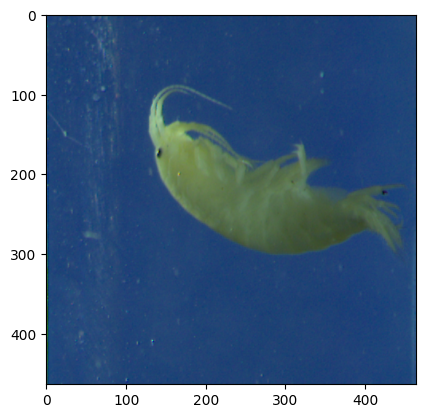

In [10]:
# Task 1.1
from keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/Week6/Bugs.PNG'
img = load_img(img_path)

print(type(img))
print(img.format)
print(img.mode)
print(img.size)

plt.imshow(img)
plt.show()

In [11]:
# Task 1.2
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import array_to_img

img = load_img('/content/drive/MyDrive/Week6/Bugs.PNG')
print(type(img))

img = img_to_array(img)
print(img.dtype)
print(img.shape)

img = array_to_img(img)
print(type(img))

<class 'PIL.PngImagePlugin.PngImageFile'>
float32
(464, 464, 3)
<class 'PIL.Image.Image'>


<class 'PIL.Image.Image'>
None
RGB
(464, 464)


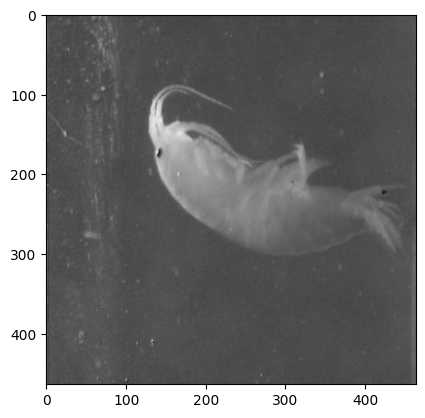

In [14]:
# Task 1.3
from keras.preprocessing.image import load_img
from keras.preprocessing.image import save_img
from keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt

img = load_img('/content/drive/MyDrive/Week6/Bugs.PNG', color_mode='grayscale')

img = img_to_array(img)

save_img('bug_grayscale.jpg', img)

img = load_img('bug_grayscale.jpg')

print(type(img))
print(img.format)
print(img.mode)
print(img.size)

plt.imshow(img, cmap='gray')
plt.show()

In [15]:
# Task 1.4
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print('Train', train_images.shape, train_labels.shape)
print('Test', test_images.shape, test_labels.shape)

print('Train', train_images.min(), train_images.max(), train_images.mean(), train_images.std())
print('Test', test_images.min(), test_images.max(), test_images.mean(), test_images.std())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train (60000, 28, 28) (60000,)
Test (10000, 28, 28) (10000,)
Train 0 255 33.318421449829934 78.56748998339798
Test 0 255 33.791224489795916 79.17246322228644


In [16]:
# Task 1.5
# example of normalizing an image dataset (MNIST)
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# load dataset
(trainX, trainY), (testX, testY) = mnist.load_data()

# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height, channels))
testX = testX.reshape((testX.shape[0], width, height, channels))

# confirm scale of pixels
print('Train min=%.3f, max=%.3f' % (trainX.min(), trainX.max()))
print('Test min=%.3f, max=%.3f' % (testX.min(), testX.max()))

# create generator (1.0/255.0 = 0.003921568627451)
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Note: there is no need to fit the generator in this case
# prepare iterators to scale images
train_iterator = datagen.flow(trainX, trainY, batch_size=64)
test_iterator = datagen.flow(testX, testY, batch_size=64)

print('Batches train=%d, test=%d' % (len(train_iterator),
len(test_iterator)))

# confirm the scaling works
batchX, batchY = next(train_iterator)
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape,
batchX.min(), batchX.max()))

Train min=0.000, max=255.000
Test min=0.000, max=255.000
Batches train=938, test=157
Batch shape=(64, 28, 28, 1), min=0.000, max=1.000


In [21]:
# Task 1.6
# example of centering a image dataset
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# load dataset
(trainX, trainY), (testX, testY) = mnist.load_data()

# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height,
channels))
testX = testX.reshape((testX.shape[0], width, height,
channels))

# report per-image mean
print('Means train=%.3f, test=%.3f' % (trainX.mean(),
testX.mean()))

# create generator that centers pixel values
datagen = ImageDataGenerator(featurewise_center=True)

# calculate the mean on the training dataset
datagen.fit(trainX)
print('Data Generator Mean: %.3f' % datagen.mean.item())

# demonstrate effect on a single batch of samples
iterator = datagen.flow(trainX, trainY, batch_size=64)

# get a batch
batchX, batchY = next(iterator)

# mean pixel value in the batch
print(batchX.shape, batchX.mean())

# demonstrate effect on entire training dataset
iterator = datagen.flow(trainX, trainY,
batch_size=len(trainX), shuffle=False)

# get a batch
batchX, batchY = next(iterator)

# mean pixel value in the batch
print(batchX.shape, batchX.mean())

Means train=33.318, test=33.791
Data Generator Mean: 33.318
(64, 28, 28, 1) 0.35860875
(60000, 28, 28, 1) -1.9512918e-05


In [22]:
# Task 1.7
# example of standardizing a image dataset
from keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# load dataset
(trainX, trainY), (testX, testY) = mnist.load_data()

# reshape dataset to have a single channel
width, height, channels = trainX.shape[1], trainX.shape[2], 1
trainX = trainX.reshape((trainX.shape[0], width, height, channels))
testX = testX.reshape((testX.shape[0], width, height, channels))

# report pixel means and standard deviations
print('Statistics train=%.3f (%.3f), test=%.3f (%.3f)' % (trainX.mean(), trainX.std(),
testX.mean(), testX.std()))

# create generator that centers pixel values
datagen = ImageDataGenerator(featurewise_center=True,
featurewise_std_normalization=True)

# calculate the mean on the training dataset
datagen.fit(trainX)
print('Data Generator mean=%.3f, std=%.3f' % (datagen.mean.item(),
datagen.std.item()))

# demonstrate effect on a single batch of samples
iterator = datagen.flow(trainX, trainY, batch_size=64)

# get a batch
batchX, batchY = next(iterator)

# pixel stats in the batch
print(batchX.shape, batchX.mean(), batchX.std())

# demonstrate effect on entire training dataset
iterator = datagen.flow(trainX, trainY, batch_size=len(trainX), shuffle=False)

# get a batch
batchX, batchY = next(iterator)

# pixel stats in the batch
print(batchX.shape, batchX.mean(), batchX.std())

Statistics train=33.318 (78.567), test=33.791 (79.172)
Data Generator mean=33.318, std=78.567
(64, 28, 28, 1) 0.012333096 1.0126644
(60000, 28, 28, 1) -3.4560264e-07 0.9999998
